In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('../../../Data/ushape.csv')

In [14]:
df.rename(columns={'3.159499363321345566e-02': 'X'}, inplace=True)
df.rename(columns={'9.869877579082642072e-01': 'Y'}, inplace=True)
df.rename(columns={'0.000000000000000000e+00': 'class'}, inplace=True)

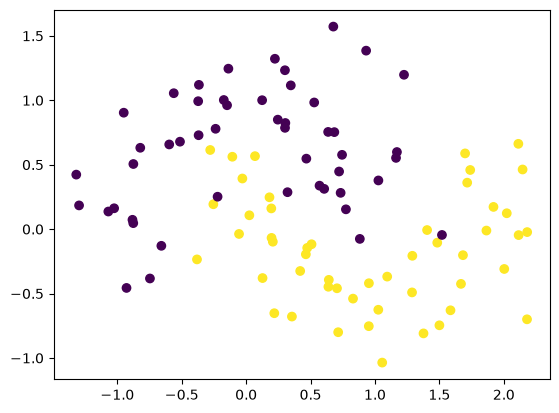

In [15]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [16]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [17]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Input

In [18]:
model = Sequential()

model.add(Input(shape=(2,)))
model.add(Dense(10, activation='relu', kernel_initializer='he_normal'))
model.add(Dense(10, activation='relu', kernel_initializer='he_normal'))
model.add(Dense(10, activation='relu', kernel_initializer='he_normal'))
model.add(Dense(10, activation='relu', kernel_initializer='he_normal'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.get_weights()

[array([[-0.02787146, -1.7718018 , -0.7213159 ,  0.6125872 , -0.19650091,
         -0.97297937, -0.7318334 ,  1.6704704 ,  1.6816826 ,  0.33224398],
        [-2.191668  ,  0.00806717,  1.020216  , -1.5340436 ,  0.62888515,
         -0.5459613 ,  1.4767916 ,  1.0134287 , -0.13261732, -1.6895872 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.25580445,  0.42300782,  0.43902054,  0.0325061 , -0.07366223,
         -0.4120944 ,  0.3165642 , -0.81688493, -0.85583484, -0.26280528],
        [-0.5784238 , -0.5639179 , -0.04642952, -0.45245788, -0.13459612,
         -0.4223502 ,  0.42276692,  0.9055624 , -0.4489672 , -0.9515744 ],
        [ 0.39538905,  0.42043653, -0.20290992,  0.01990835, -0.24357854,
          0.3339533 ,  0.62109506, -0.26663724,  0.32802162,  0.05469905],
        [ 0.9903266 ,  0.5490905 , -0.03572196,  0.6556224 , -0.2612927 ,
         -0.02145377,  0.03535713, -0.4269706 , -0.28486395,  0.0580668 ],
        [-0.19161

In [20]:
initial_weights = model.get_weights()

In [21]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [22]:
model.set_weights(initial_weights)

In [23]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [24]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.4937 - loss: 0.6999 - val_accuracy: 0.4000 - val_loss: 0.7027
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4937 - loss: 0.6978 - val_accuracy: 0.4500 - val_loss: 0.6997
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4557 - loss: 0.6959 - val_accuracy: 0.4500 - val_loss: 0.6970
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4937 - loss: 0.6940 - val_accuracy: 0.6000 - val_loss: 0.6944
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6076 - loss: 0.6923 - val_accuracy: 0.7000 - val_loss: 0.6918
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6329 - loss: 0.6908 - val_accuracy: 0.8000 - val_loss: 0.6894
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7342 - loss: 0.6893 - val_accuracy: 0.9000 - val_loss: 0.6870
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7468 - loss: 0.6881 - val_accuracy: 0.9000 - val_loss:

<Axes: >

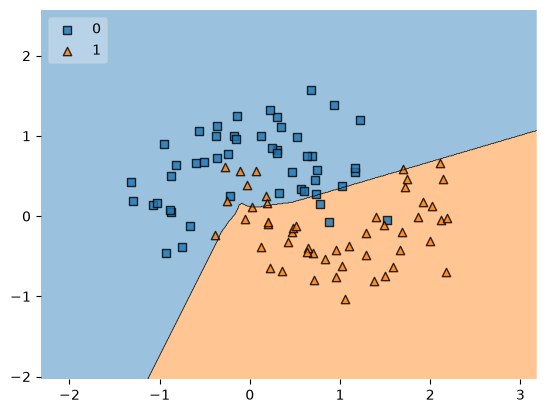

In [25]:
from mlxtend.plotting import plot_decision_regions

class KerasBinaryClassifier:
    def __init__(self, model, threshold=0.5):
        self.model = model
        self.threshold = threshold

    def predict(self, X):
        probabilities = self.model.predict(X, verbose=0)
        return (probabilities.ravel() >= self.threshold).astype(int)

plot_decision_regions(X, y.astype(int), clf=KerasBinaryClassifier(model), legend=2)